In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Geometry

kfactory uses [KLayout](https://www.klayout.de/)'s geometry primitives directly.
Every shape lives on an integer grid called the **database unit (DBU)** grid.
The default grid is 1 nm (1 DBU = 0.001 µm).

Two parallel APIs exist for every shape type:

| DBU (integer) | Microns (float) | Conversion |
|---------------|-----------------|------------|
| `Point`       | `DPoint`        | `kcl.to_dbu(dp)` / `kcl.to_um(p)` |
| `Box`         | `DBox`          | same |
| `Polygon`     | `DPolygon`      | same |
| `Edge`        | `DEdge`         | same |
| `Region`      | —               | DBU only |

Use the **D-variants** (microns) when writing component code; use the **integer
variants** only when you need to interact with `Region` or read back raw DBU
coordinates.

In [2]:
import numpy as np

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    CLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(4, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## Basic shape primitives

### DBox — axis-aligned rectangle

`DBox(left, bottom, right, top)` or `DBox(width, height)` (centred at origin).

In [3]:
box_um = kf.kdb.DBox(-2.5, -5, 2.5, 5)  # 5 µm wide, 10 µm tall, centred
box_um

(-2.5,-5;2.5,5)

In [4]:
# Convert to DBU integers for low-level operations
box_dbu = kf.kcl.to_dbu(box_um)
print(f"DBU: {box_dbu}")
print(f"DBU width : {box_dbu.width()} nm")
print(f"µm  width : {box_um.width()} µm")

DBU: (-2500,-5000;2500,5000)
DBU width : 5000 nm
µm  width : 5.0 µm


### DPolygon — arbitrary polygon in microns

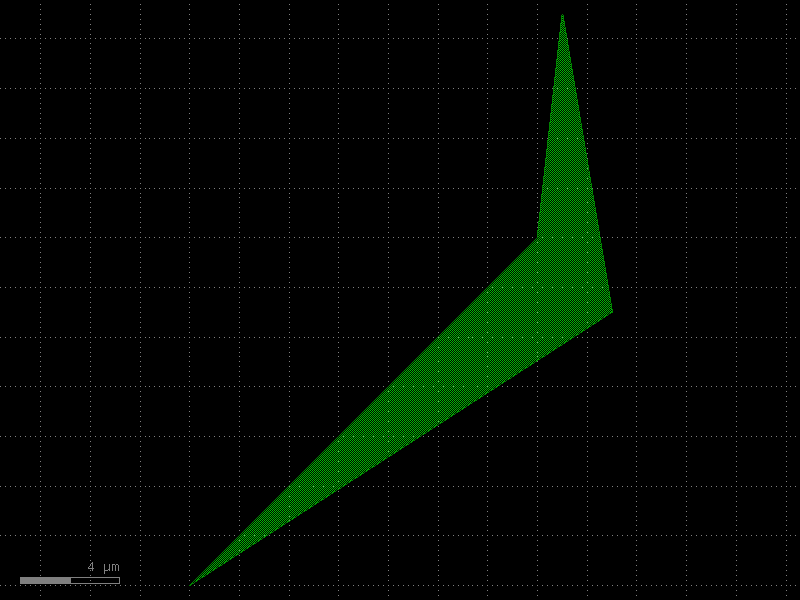

In [5]:
# From a list of DPoint objects
poly_a = kf.kdb.DPolygon(
    [
        kf.kdb.DPoint(-8, -6),
        kf.kdb.DPoint(6, 8),
        kf.kdb.DPoint(7, 17),
        kf.kdb.DPoint(9, 5),
    ]
)

# Convenience wrapper: pass a NumPy array of (x, y) pairs
points = np.array([(-8, -6), (6, 8), (7, 17), (9, 5)])
poly_b = kf.polygon_from_array(points)

# Both produce equivalent polygons
c = kf.KCell(name="polygon_demo")
c.shapes(kf.kcl.find_layer(L.WG)).insert(poly_a)
c.shapes(kf.kcl.find_layer(L.WGEX)).insert(poly_b)
c.plot()

### DPolygon — ellipse helper

`DPolygon.ellipse(bbox, n_points)` inscribes an ellipse inside `bbox`.

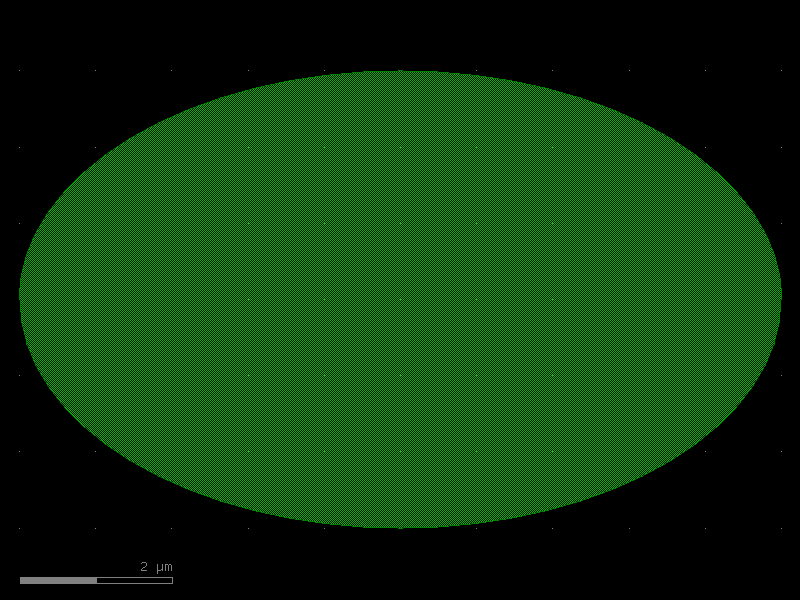

In [6]:
ellipse = kf.kdb.DPolygon.ellipse(kf.kdb.DBox(10, 6), 64)
e_cell = kf.KCell(name="ellipse_demo")
e_cell.shapes(kf.kcl.find_layer(L.WG)).insert(ellipse)
e_cell.plot()

## Inserting shapes into a cell

All shapes live inside a cell on a specific layer.
`cell.shapes(layer_index).insert(shape)` adds the shape to that layer.

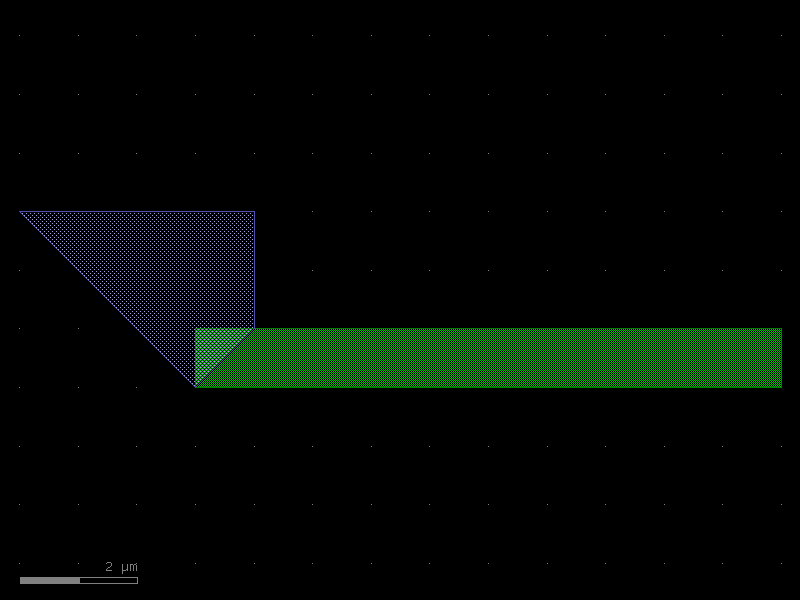

In [7]:
c = kf.KCell(name="shapes_on_layers")

# Box on WG layer
c.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(0, 0, 10, 1))

# Polygon on CLAD layer (list-of-points style)
c.shapes(kf.kcl.find_layer(L.CLAD)).insert(
    kf.kdb.DPolygon([kf.kdb.DPoint(x, y) for x, y in ((0, 0), (1, 1), (1, 3), (-3, 3))])
)

c.plot()

## Transformations

Shapes can be transformed with `shape.transformed(trans)`.

| Class | Description |
|-------|-------------|
| `DTrans(x, y)` | Translate by (x, y) µm (and optionally rotate 0/90/180/270 °) |
| `DCplxTrans(mag, angle_deg, mirror, x, y)` | Arbitrary rotation + magnification |

> **Note:** `DCplxTrans` magnification is only safe on plain shapes; foundries
> typically disallow it on cell instances.

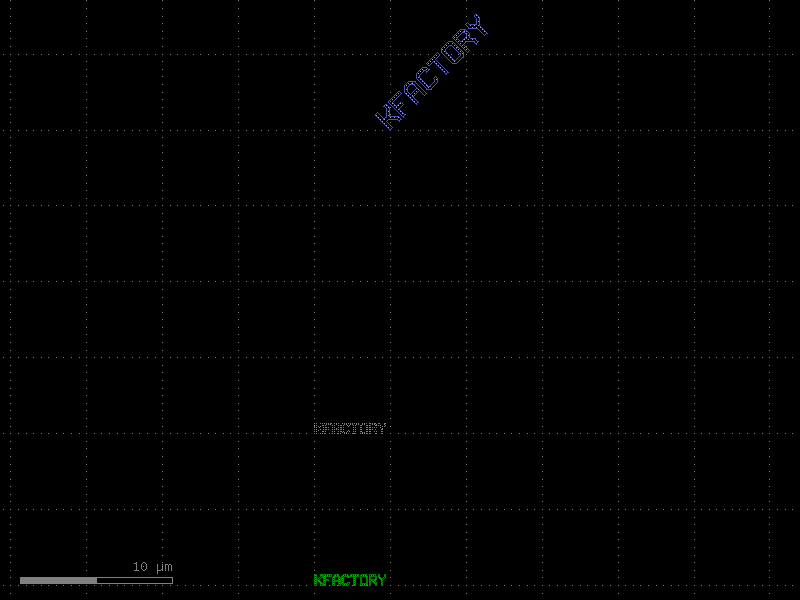

In [8]:
textgen = kf.kdb.TextGenerator.default_generator()
text_region = textgen.text("kfactory", kf.kcl.dbu)

c = kf.KCell(name="text_transforms")
# Place text at origin
c.shapes(kf.kcl.find_layer(L.WG)).insert(text_region)
# Translate +10 µm in y
c.shapes(kf.kcl.find_layer(L.WGEX)).insert(
    text_region.transformed(kf.kdb.DTrans(0, 10.0).to_itype(kf.kcl.dbu))
)
# Rotate 45° and scale ×2
c.shapes(kf.kcl.find_layer(L.CLAD)).insert(
    text_region.transformed(
        kf.kdb.DCplxTrans(2.0, 45.0, False, 5.0, 30.0).to_itrans(kf.kcl.dbu)
    )
)
c.plot()

## Labels (GDS text annotations)

Labels record metadata directly in the GDS file (e.g. port names, cell IDs).
They are not fabricated — use `kf.kdb.Text` for labels and polygon-based text
(via `TextGenerator`) for visible text shapes.

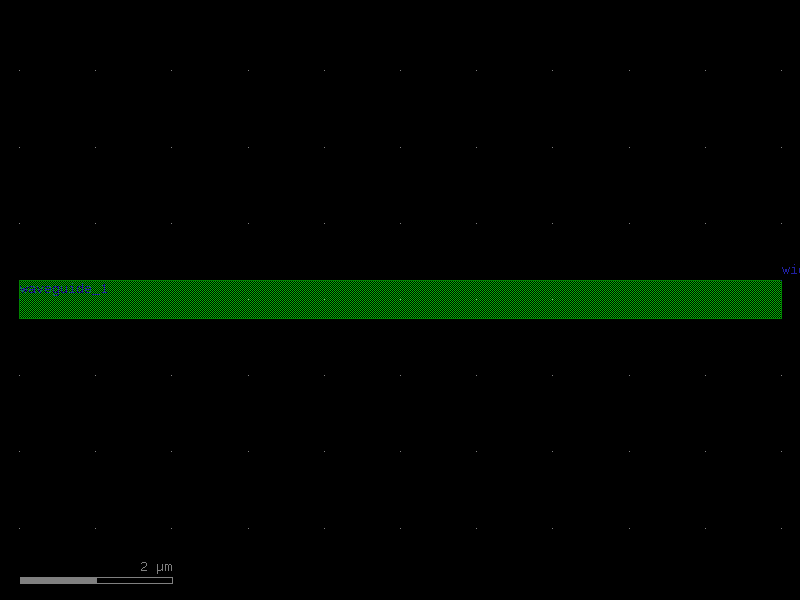

In [9]:
anno = kf.KCell(name="label_demo")
s = kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)
inst = anno << s

# Attach a label at the instance origin
anno.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(
    kf.kdb.Text("waveguide_1", inst.trans)
)
# Dynamic label: embed a measurement
anno.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(
    kf.kdb.Text(
        f"width={anno.dbbox().width():.1f}um",
        kf.kdb.Trans(anno.bbox().right, anno.bbox().top),
    )
)
anno.plot()

## Boolean Region operations

`kf.kdb.Region` is a set of DBU polygons that supports boolean algebra.
Convert a `DPolygon` to a `Region` with `kcl.to_dbu(poly)` first.

| Operator | Meaning |
|----------|---------|
| `A - B`  | A NOT B (subtract) |
| `A & B`  | A AND B (intersection) |
| `A + B`  | A OR B (union, may overlap) |
| `(A + B).merge()` | union, merged into minimal polygon set |
| `A ^ B`  | A XOR B (symmetric difference) |

In [10]:
# Two overlapping ellipses
e1 = kf.kdb.DPolygon.ellipse(kf.kdb.DBox(10, 8), 64)
e2 = kf.kdb.DPolygon.ellipse(kf.kdb.DBox(10, 6), 64).transformed(
    kf.kdb.DTrans(2.0, 0.0)
)


# Helper: make a demo cell with the result of a Region operation
def _show(name: str, region: kf.kdb.Region) -> kf.KCell:
    c = kf.KCell(name=name)
    c.shapes(kf.kcl.find_layer(L.WG)).insert(region)
    return c


r1 = kf.kdb.Region(kf.kcl.to_dbu(e1))
r2 = kf.kdb.Region(kf.kcl.to_dbu(e2))

### NOT (A − B)

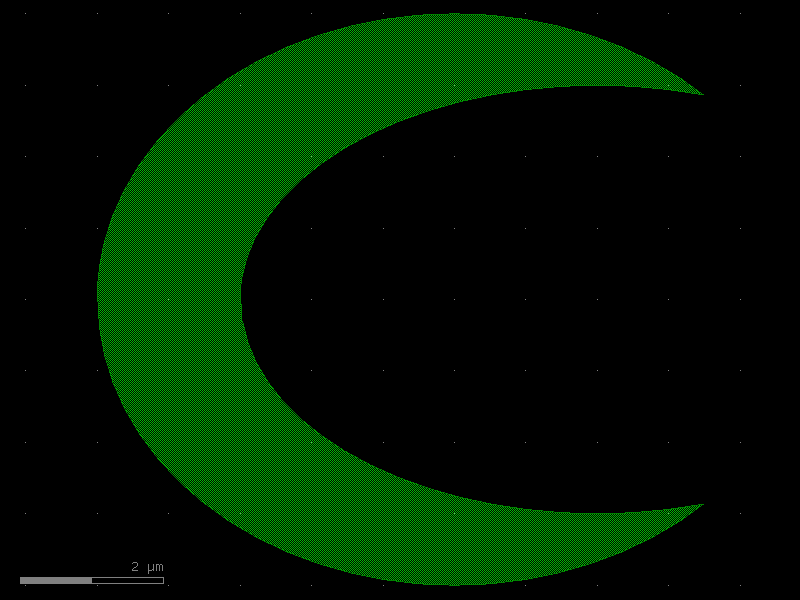

In [11]:
_show("not_demo", r1 - r2).plot()

### AND (A ∩ B)

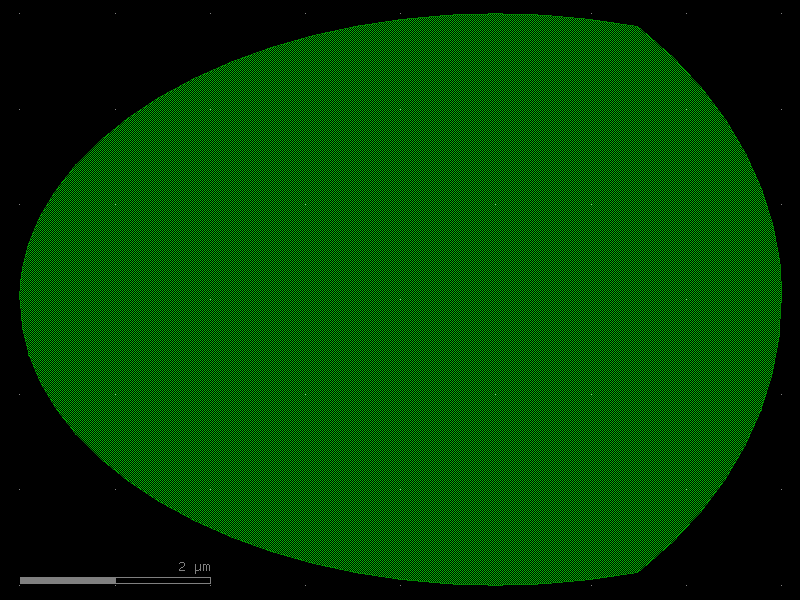

In [12]:
_show("and_demo", r1 & r2).plot()

### OR / union (A + B)

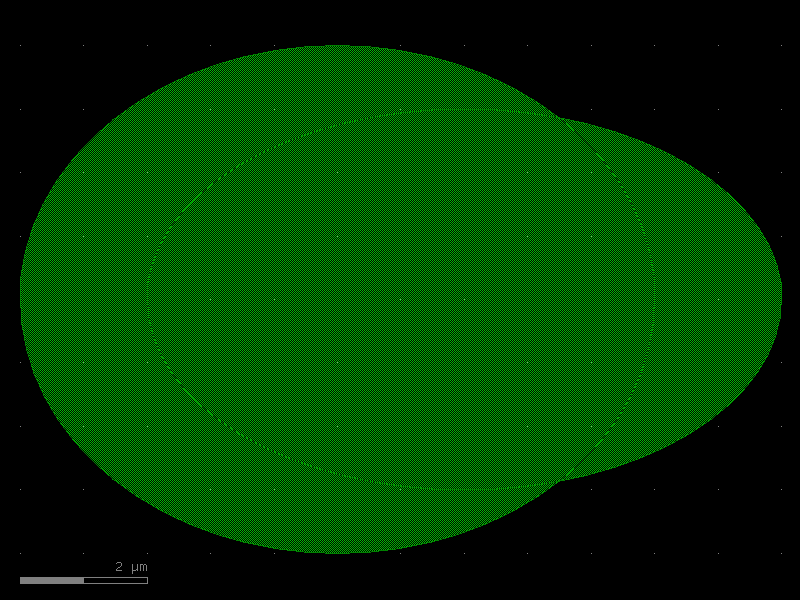

In [13]:
_show("or_demo", r1 + r2).plot()

### OR merged — single-polygon result after `.merge()`

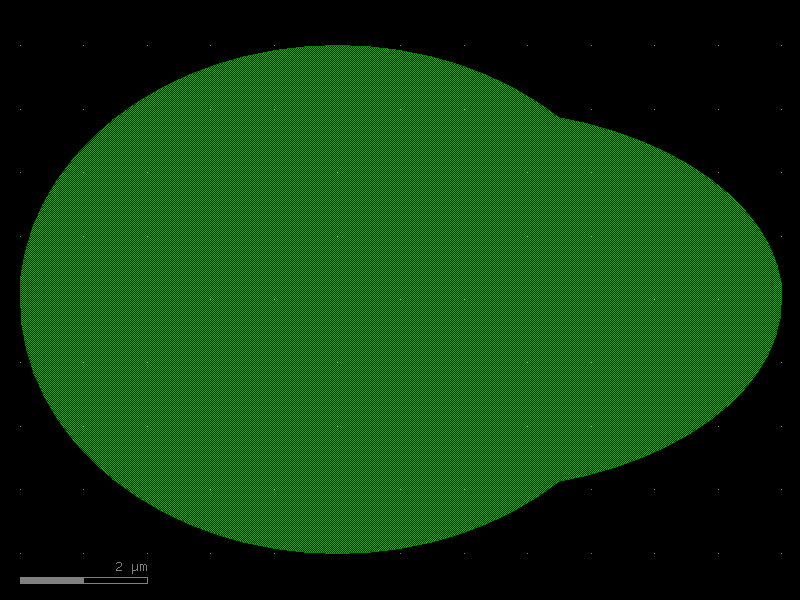

In [14]:
_show("or_merged_demo", (r1 + r2).merge()).plot()

### XOR (A ⊕ B)

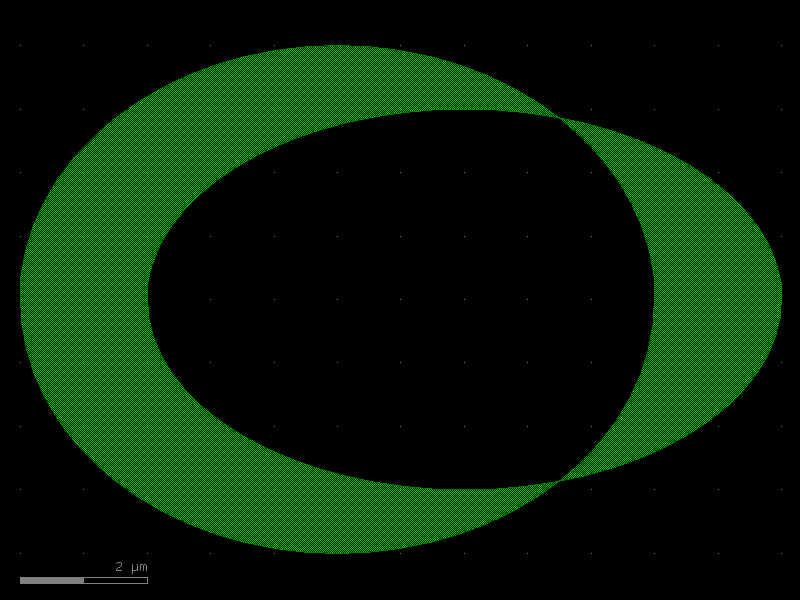

In [15]:
_show("xor_demo", r1 ^ r2).plot()

## Writing a GDS file

Call `cell.write("output.gds")` to export to GDSII format.

In [16]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmp:
    out = Path(tmp) / "demo_geometry.gds"
    anno.write(str(out))
    print(f"Wrote {out.name} ({out.stat().st_size} bytes)")

Wrote demo_geometry.gds (1012 bytes)


## Summary

| Task | API |
|------|-----|
| Rectangle in µm | `kf.kdb.DBox(left, bottom, right, top)` |
| Polygon in µm | `kf.kdb.DPolygon([DPoint(...), ...])` |
| Polygon from array | `kf.polygon_from_array(np_array)` |
| Ellipse | `kf.kdb.DPolygon.ellipse(bbox, n_pts)` |
| Convert µm → DBU | `kf.kcl.to_dbu(shape)` |
| Convert DBU → µm | `kf.kcl.to_um(shape)` |
| Add shape to cell | `cell.shapes(layer_idx).insert(shape)` |
| Boolean subtract | `Region(a) - Region(b)` |
| Boolean intersect | `Region(a) & Region(b)` |
| Boolean union | `(Region(a) + Region(b)).merge()` |
| Boolean XOR | `Region(a) ^ Region(b)` |
| GDS text label | `kf.kdb.Text("label", trans)` |
| Export GDS | `cell.write("file.gds")` |

## See Also

| Topic | Where |
|-------|-------|
| DRC spacing fixes (Region-based) | [Utilities: DRC Fixing](../utilities/drc_fix.py) |
| Auto-cladding via Minkowski sum | [Enclosures: Layer Enclosure](../enclosures/layer_enclosure.py) |
| Fill tiling with Region exclusions | [Utilities: Fill](../utilities/fill.py) |